In [1]:
import pandas as pd

In [2]:
air=pd.read_csv("air_quality.csv")
heart=pd.read_csv("heart.csv")

In [3]:
air=air.dropna()
heart=heart.dropna()

In [26]:
air=air.drop_duplicates()
heart=heart.drop_duplicates()

In [34]:
print(heart.head())
print(air.head())





   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
                                                                              Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2 6;1360;150;11 9;1046;166;1056;113;1692;1268;13 6;48 9;0                                             7578;;                                                  

In [37]:
if isinstance(air.columns,pd.MultiIndex):
   air.columns=air.columns.get_level_values(0)

if isinstance(heart.columns,pd.MultiIndex):
   heart.columns=heart.columns.get_level_values(0)

air=air.reset_index(drop=True)
heart=heart.reset_index(drop=True)

data=pd.concat([air,heart],axis=1)

data=data.dropna()
print(data)

    Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;  \
0                                               7578;;                                                                             
1                                               7502;;                                                                             
2                                               7867;;                                                                             
3                                               7888;;                                                                             
4                                               7848;;                                                                             
..                                                 ...                                                                             
297                                             8429;;                      

In [39]:
data=data[data["age"] <= 100]

In [40]:
data

,Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,7578;;,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2.0,3.0,0.0
1,7502;;,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0.0,3.0,0.0
2,7867;;,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0.0,3.0,0.0
3,7888;;,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1.0,3.0,0.0
4,7848;;,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,8429;;,68.0,0.0,2.0,120.0,211.0,0.0,0.0,115.0,0.0,1.5,1.0,0.0,2.0,1.0
298,8415;;,44.0,0.0,2.0,108.0,141.0,0.0,1.0,175.0,0.0,0.6,1.0,0.0,2.0,1.0
299,8389;;,52.0,1.0,0.0,128.0,255.0,0.0,1.0,161.0,1.0,0.0,2.0,1.0,3.0,0.0
300,8447;;,59.0,1.0,3.0,160.0,273.0,0.0,0.0,125.0,0.0,0.0,2.0,0.0,2.0,0.0


In [59]:
data["age"]=pd.to_numeric(data["age"], errors="coerce")
data["trestbps"] = pd.to_numeric(data["trestbps"], errors='coerce')
data["chol"] = pd.to_numeric(data["chol"], errors='coerce')
data=data.dropna()

In [45]:
print(data)

    Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;  \
0                                               7578;;                                                                             
1                                               7502;;                                                                             
2                                               7867;;                                                                             
3                                               7888;;                                                                             
4                                               7848;;                                                                             
..                                                 ...                                                                             
297                                             8429;;                      

In [49]:
from sklearn.linear_model import LogisticRegression

In [70]:
data = data.dropna()



x=data[["age","chol","trestbps"]]
y=data["target"]

model=LogisticRegression()
model.fit(x,y)

import pandas as pd
test=pd.DataFrame([[25,120,200]],columns=["age","chol","trestbps"])

pred=model.predict(test)
print(pred)

if pred[0]==1:
  print("Has Heart Disease")
else:
  print("No")

[1.]
Has Heart Disease


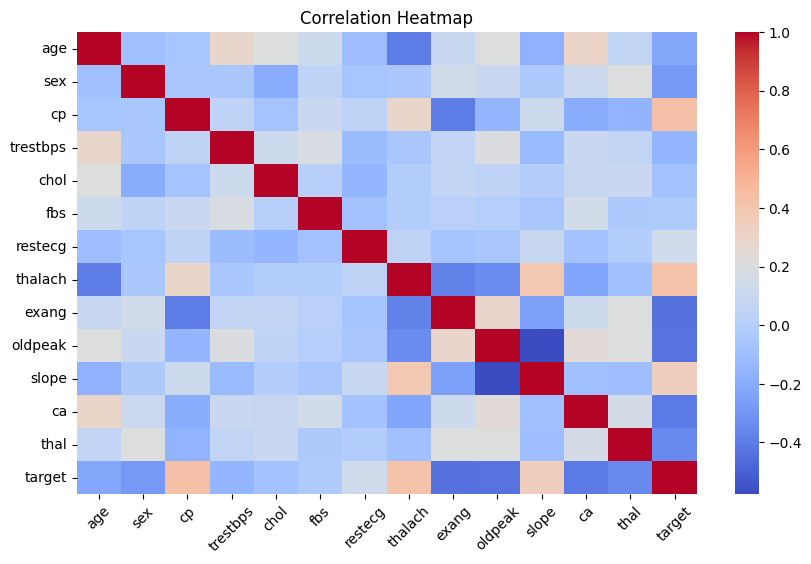

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))


corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()



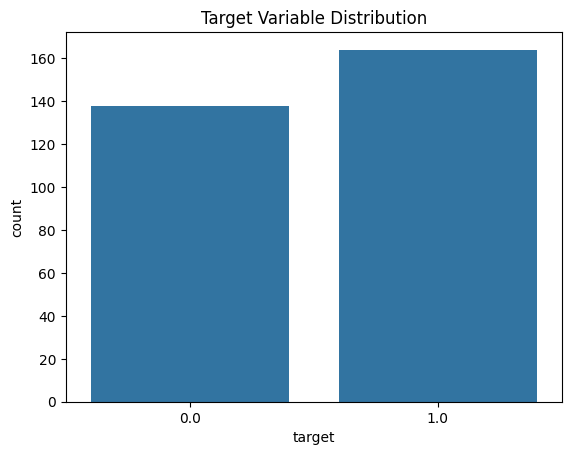

In [74]:
# Target count plot
if 'target' in data.columns:
    sns.countplot(x='target', data=data)
    plt.title("Target Variable Distribution")
    plt.show()